In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

from PIL import Image
import json
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
import numpy as np

from DL.models import CustomClassifierFromConfig
from DL.trainer import ModelTrainer
from DL.visualize import (show_batch, visualize_all_classes_gradcam,
                          plot_confusion_matrices, visualize_overlay_gradcam, visualize_multilayer_gradcam)
from mnist_synthetic.lower_case_letters_generator import LowerCaseLettersGenerator
from mnist_synthetic.torch.datasets import MNISTSynthetic
from mnist_synthetic.generator import NumbersGenerator
from mnist_synthetic.config import GeneratorConfig

# Скрываем предупреждения
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


C:\Users\Computer\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Параметры аугментации (из статьи)
perspective_transform = T.RandomPerspective(distortion_scale=0.5, p=0.8)

# Класс для синтетических кириллических данных
class SyntheticCyrillicDataset(Dataset):
    def __init__(self, num_samples: int, seed: int, transform=None):
        self.num_samples = num_samples
        self.generator = LowerCaseLettersGenerator(seed=seed)
        self.char_to_idx = {char: idx for idx, char in enumerate(self.generator.ALLOWS_SYMBOLS)}
        self.idx_to_char = {idx: char for char, idx in self.char_to_idx.items()}
        self.transform = transform

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        img_np, label_char = self.generator.generate()
        img_tensor = torch.from_numpy(img_np).float().unsqueeze(0) / 255.0
        if self.transform:
            img_tensor = self.transform(img_tensor)
        label_idx = self.char_to_idx[label_char]
        return img_tensor, label_idx

# Создаем датасеты для кириллицы (75k train, 25k test)
train_dataset_cyr = SyntheticCyrillicDataset(num_samples=75000, seed=42, transform=perspective_transform)
test_dataset_cyr = SyntheticCyrillicDataset(num_samples=25000, seed=123, transform=perspective_transform)

train_loader_cyr = DataLoader(train_dataset_cyr, batch_size=256, shuffle=True)
test_loader_cyr = DataLoader(test_dataset_cyr, batch_size=256, shuffle=False)

print(f"Cyrillic: Train size = {len(train_dataset_cyr)}, Test size = {len(test_dataset_cyr)}")

Cyrillic: Train size = 75000, Test size = 25000


In [3]:
class CombinedDataset(Dataset):
    def __init__(self, num_samples: int, seed: int, transform=None):
        self.num_samples = num_samples
        self.transform = transform

        # передаем transform=None, чтобы кириллица не аугментировалась дважды
        self.cyrillic_dataset = SyntheticCyrillicDataset(num_samples=num_samples // 2, seed=seed, transform=None)
        self.mnist_dataset = MNISTSynthetic(num_samples // 2, seed=seed)

        self.char_to_idx = {**self.cyrillic_dataset.char_to_idx, **{str(i): i + len(self.cyrillic_dataset.char_to_idx) for i in range(10)}}
        self.idx_to_char = {v: k for k, v in self.char_to_idx.items()}

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        if idx < self.num_samples // 2:
            # Кириллица возвращает уже готовый тензор [1, 28, 28]
            img, label_idx = self.cyrillic_dataset[idx]
        else:
            # MNIST возвращает Image и метку (возможно число)
            img, label = self.mnist_dataset[idx - self.num_samples // 2]

            # Приводим к единому формату Tensor [1, 28, 28]
            if isinstance(img, Image.Image):
                img = TF.to_tensor(img) # Автоматически делает[C, H, W] и нормализует 0..1
            elif isinstance(img, np.ndarray):
                img = torch.from_numpy(img).float()
                if img.ndim == 2:
                    img = img.unsqueeze(0)
                if img.max() > 1.0:
                    img /= 255.0
            elif isinstance(img, torch.Tensor):
                if img.ndim == 2:
                    img = img.unsqueeze(0)
                if img.max() > 1.0:
                    img /= 255.0

            label_idx = self.char_to_idx[str(label)]

        # Применяем перспективные искажения
        if self.transform:
            img = self.transform(img)

        return img, label_idx

# Датасеты и лоадеры
train_dataset_combined = CombinedDataset(num_samples=75000, seed=42, transform=perspective_transform)
test_dataset_combined = CombinedDataset(num_samples=25000, seed=123, transform=perspective_transform)

train_loader_combined = DataLoader(train_dataset_combined, batch_size=256, shuffle=True)
test_loader_combined = DataLoader(test_dataset_combined, batch_size=256, shuffle=False)

print(f"Combined: Train size = {len(train_dataset_combined)}, Test size = {len(test_dataset_combined)}")

Combined: Train size = 75000, Test size = 25000


In [4]:
def run_experiment(
    config_path: str,
    train_loader: DataLoader,
    test_loader: DataLoader,
    dataset_name: str,
    num_epochs: int = 15,
    bg_loss_alpha: float = 15.0,
    bg_loss_n: int = 2,
    show_gradcam: bool = True,
    overlay_gradcam: bool = True
):
    # 1. Загрузка конфига
    with open(config_path, 'r') as f:
        config = json.load(f)

    # Читаем длину словаря классов прямо из датасета
    num_classes = len(train_loader.dataset.char_to_idx)
    # Перезаписываем значение из JSON-конфига
    config['num_classes'] = num_classes

    # 2. Создание модели, оптимизатора, лосса
    model = CustomClassifierFromConfig(config).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # 3. Обучение
    trainer = ModelTrainer(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        use_background_loss=True,
        bg_loss_alpha=bg_loss_alpha,
        bg_loss_n=bg_loss_n
    )
    print(f"\nОбучение {dataset_name} (Классов: {num_classes})...")
    history = trainer.fit(train_loader, test_loader, epochs=num_epochs)

    test_dataset = test_loader.dataset

    # 4. Визуализация
    if show_gradcam:
        print("\nВизуализация Grad-CAM (по первому и второму слоям):")
        visualize_multilayer_gradcam(model, model, test_dataset, device, num_samples=8)

        if overlay_gradcam:
            print("\nВизуализация Grad-CAM (один слой):")
            visualize_overlay_gradcam(model, test_dataset, device, title=f"Grad-CAM (один слой): {dataset_name}")

    # 5. Матрица ошибок
    print("\nМатрица ошибок:")
    plot_confusion_matrices(model, model, test_loader, test_dataset, device)

    return model, history


Обучение 4KB Cyrillic...
Epoch 1/15


Train Loss: 2.1852 | Train Acc: 0.4708 | BG Loss: 0.0003
Val Loss: 1.2698 | Val Acc: 0.6929

Epoch 2/15


Train Loss: 1.0075 | Train Acc: 0.7467 | BG Loss: 0.0003
Val Loss: 0.8169 | Val Acc: 0.7897

Epoch 3/15


Train Loss: 0.7065 | Train Acc: 0.8191 | BG Loss: 0.0004
Val Loss: 0.6222 | Val Acc: 0.8390

Epoch 4/15


Train Loss: 0.5511 | Train Acc: 0.8570 | BG Loss: 0.0004
Val Loss: 0.4980 | Val Acc: 0.8718

Epoch 5/15


...

Train Loss: 0.2667 | Train Acc: 0.9274 | BG Loss: 0.0003
Val Loss: 0.2654 | Val Acc: 0.9276

Epoch 12/15


Train Loss: 0.2569 | Train Acc: 0.9290 | BG Loss: 0.0002
Val Loss: 0.2771 | Val Acc: 0.9228

Epoch 13/15


Train Loss: 0.2471 | Train Acc: 0.9316 | BG Loss: 0.0004
Val Loss: 0.2474 | Val Acc: 0.9300

Epoch 14/15


Train Loss: 0.2424 | Train Acc: 0.9323 | BG Loss: 0.0004
Val Loss: 0.2319 | Val Acc: 0.9366

Epoch 15/15


Train Loss: 0.2307 | Train Acc: 0.9350 | BG Loss: 0.0002
Val Loss: 0.2286 | Val Acc: 0.9352


Визуализация Grad-CAM (по первому и второму слоям):


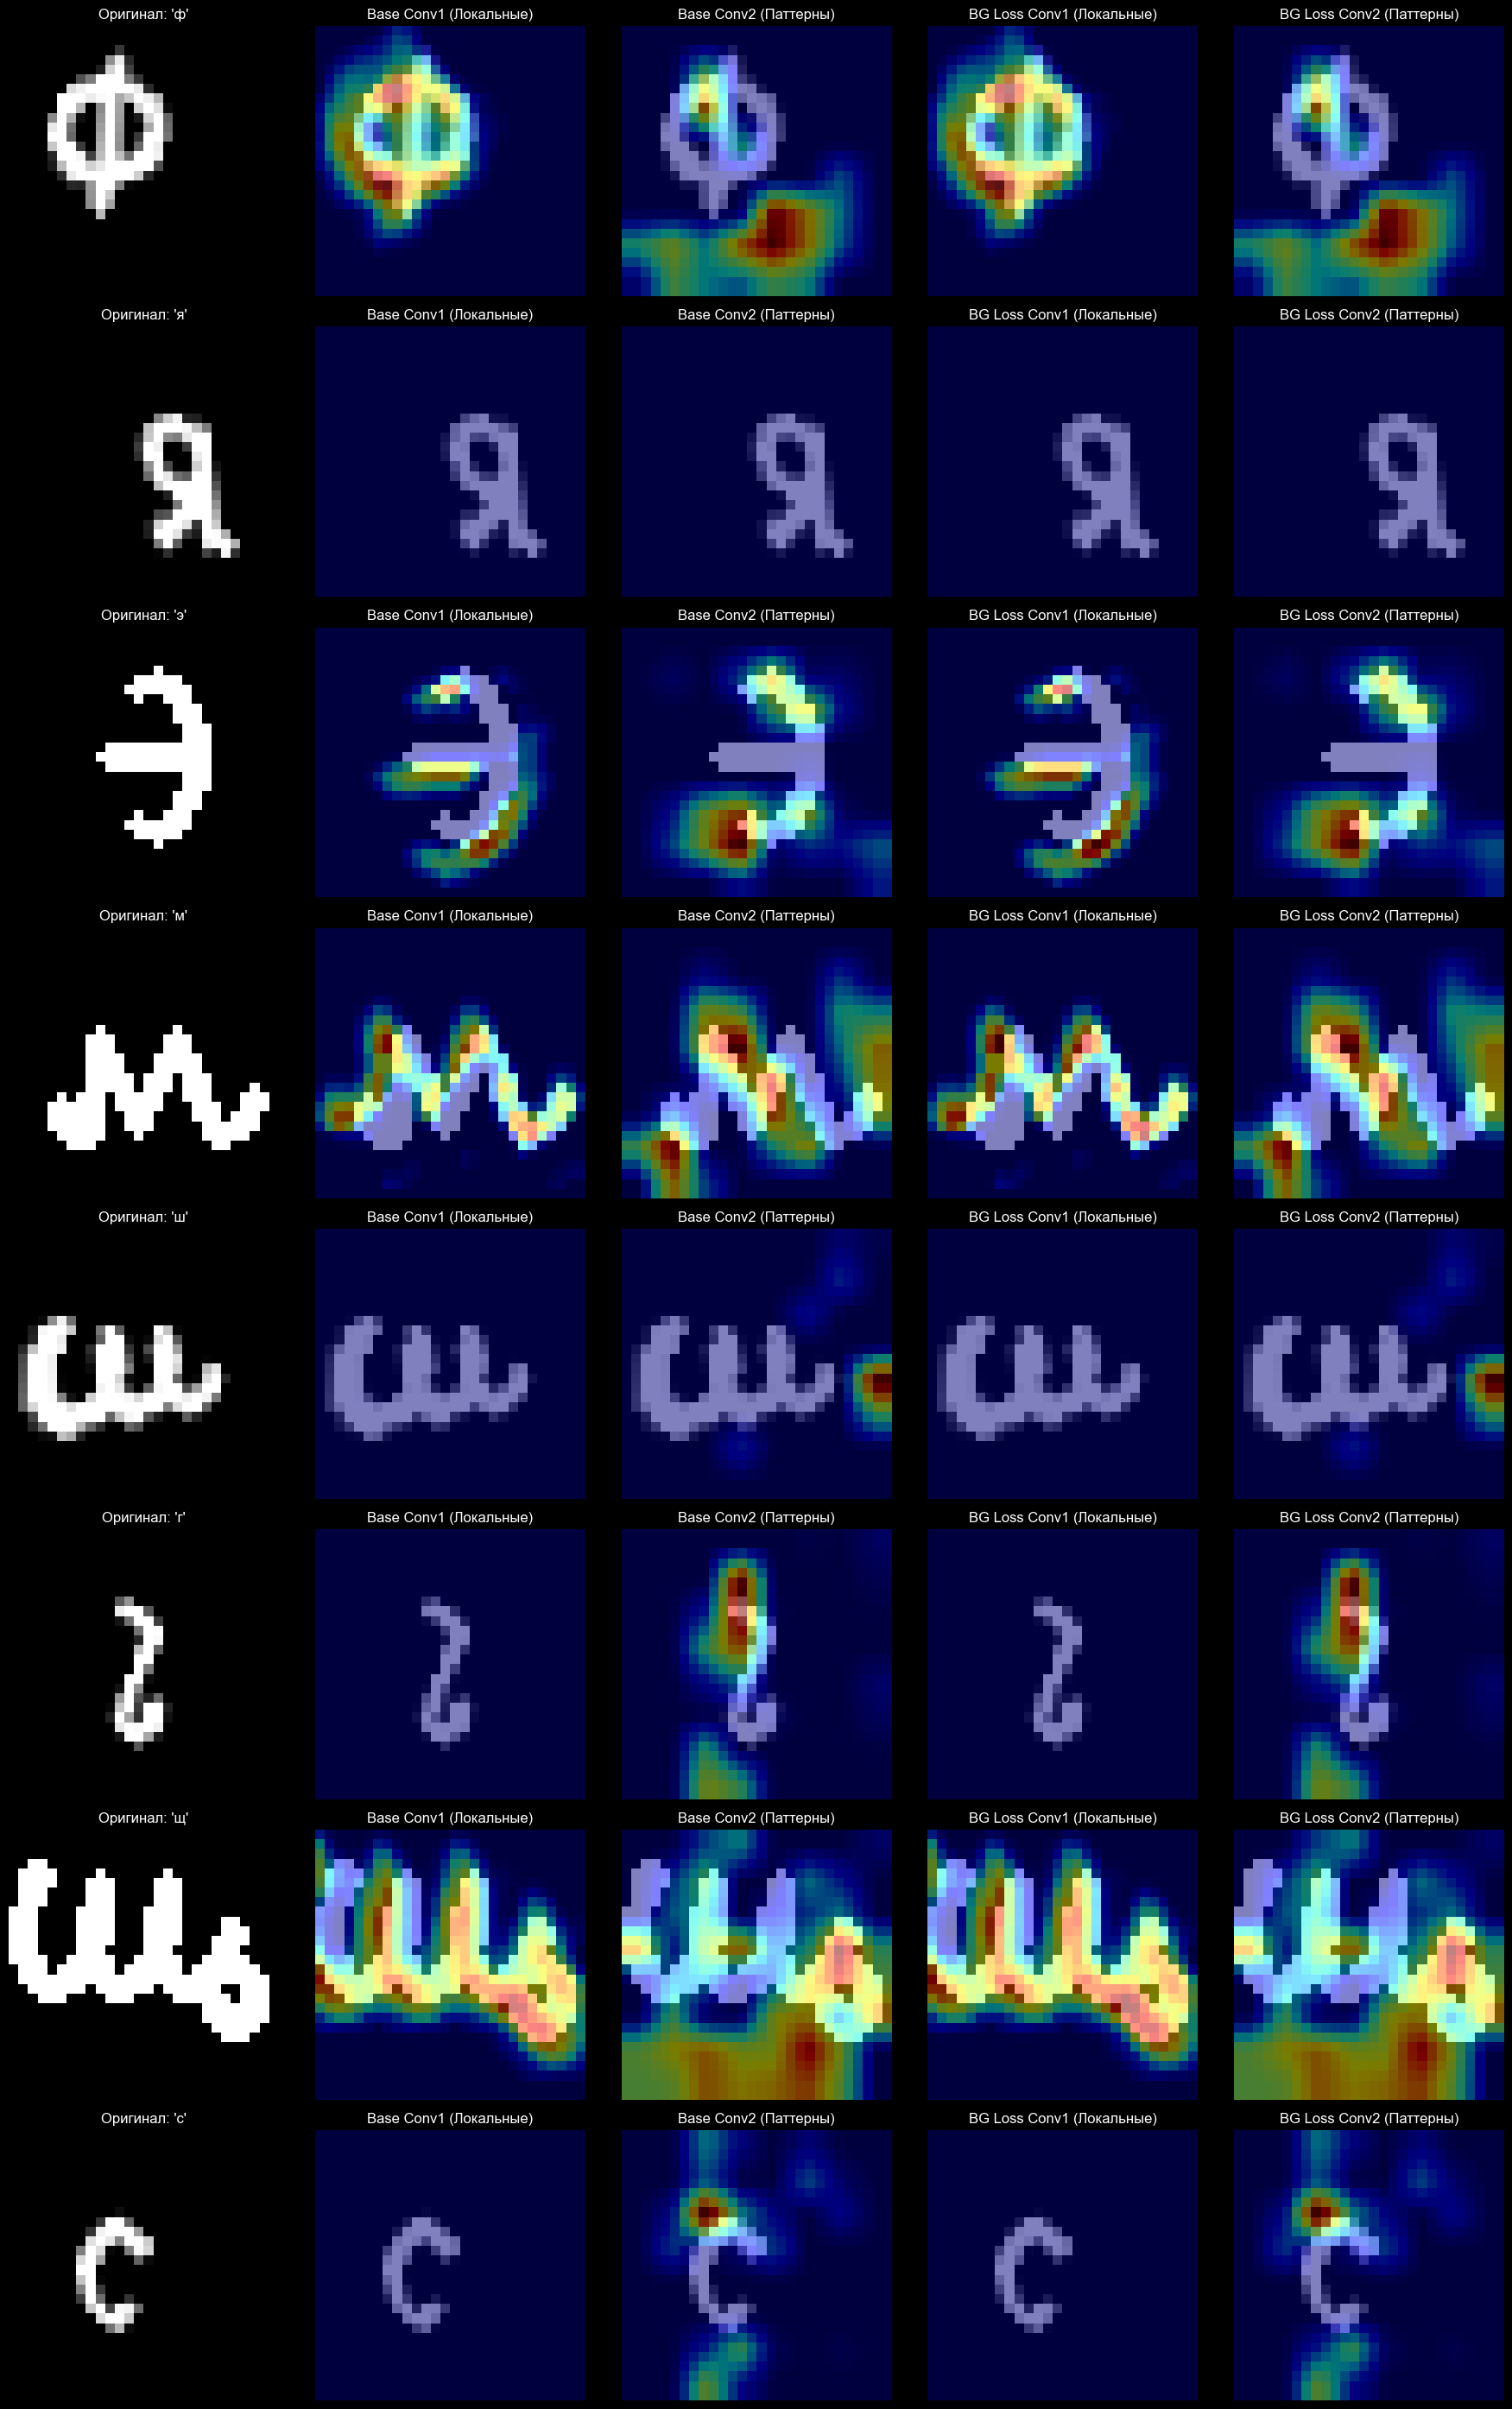


Визуализация Grad-CAM (Friend Style):


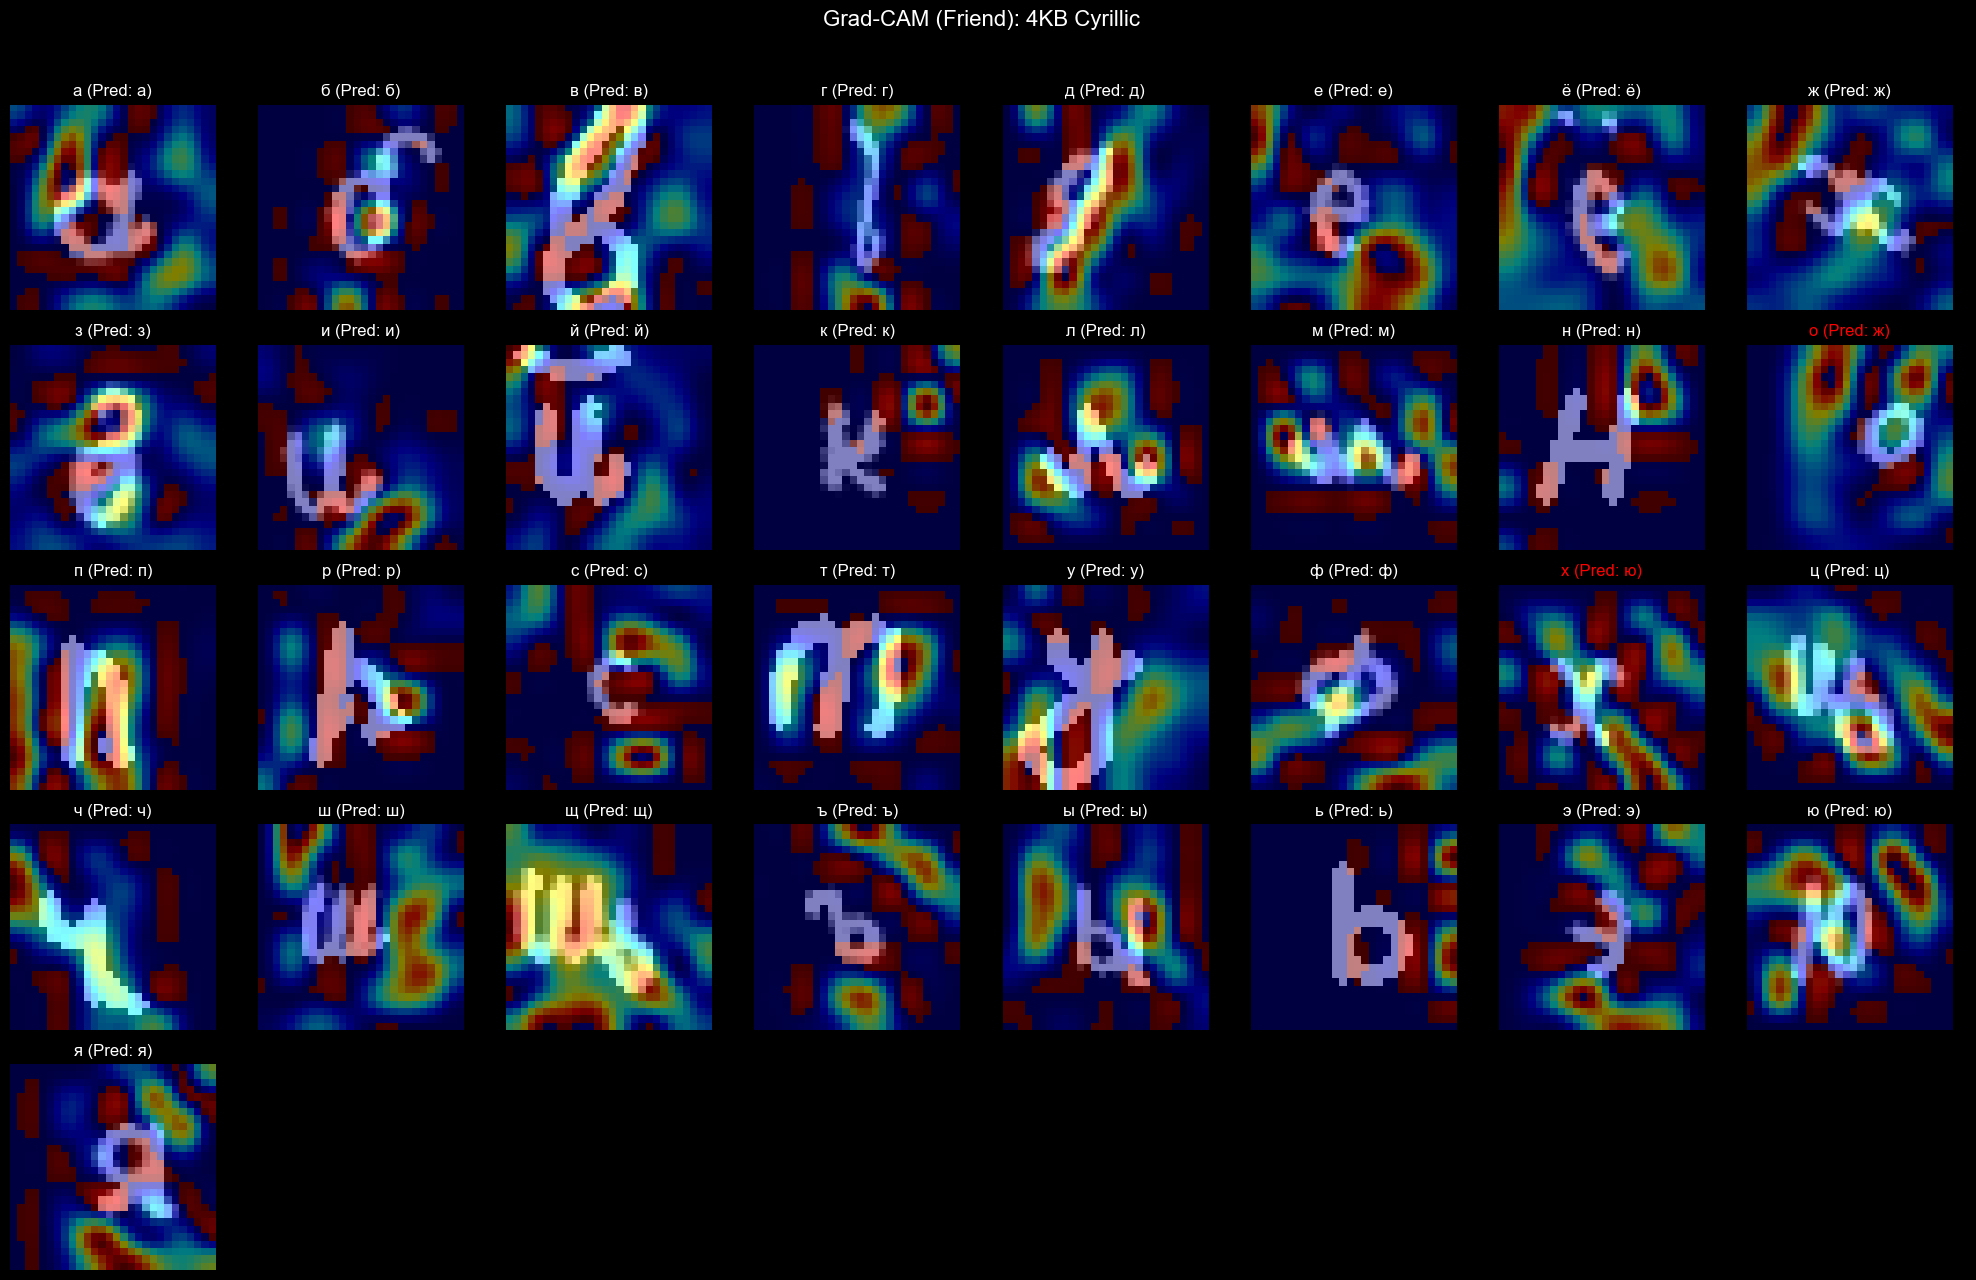


Матрица ошибок:


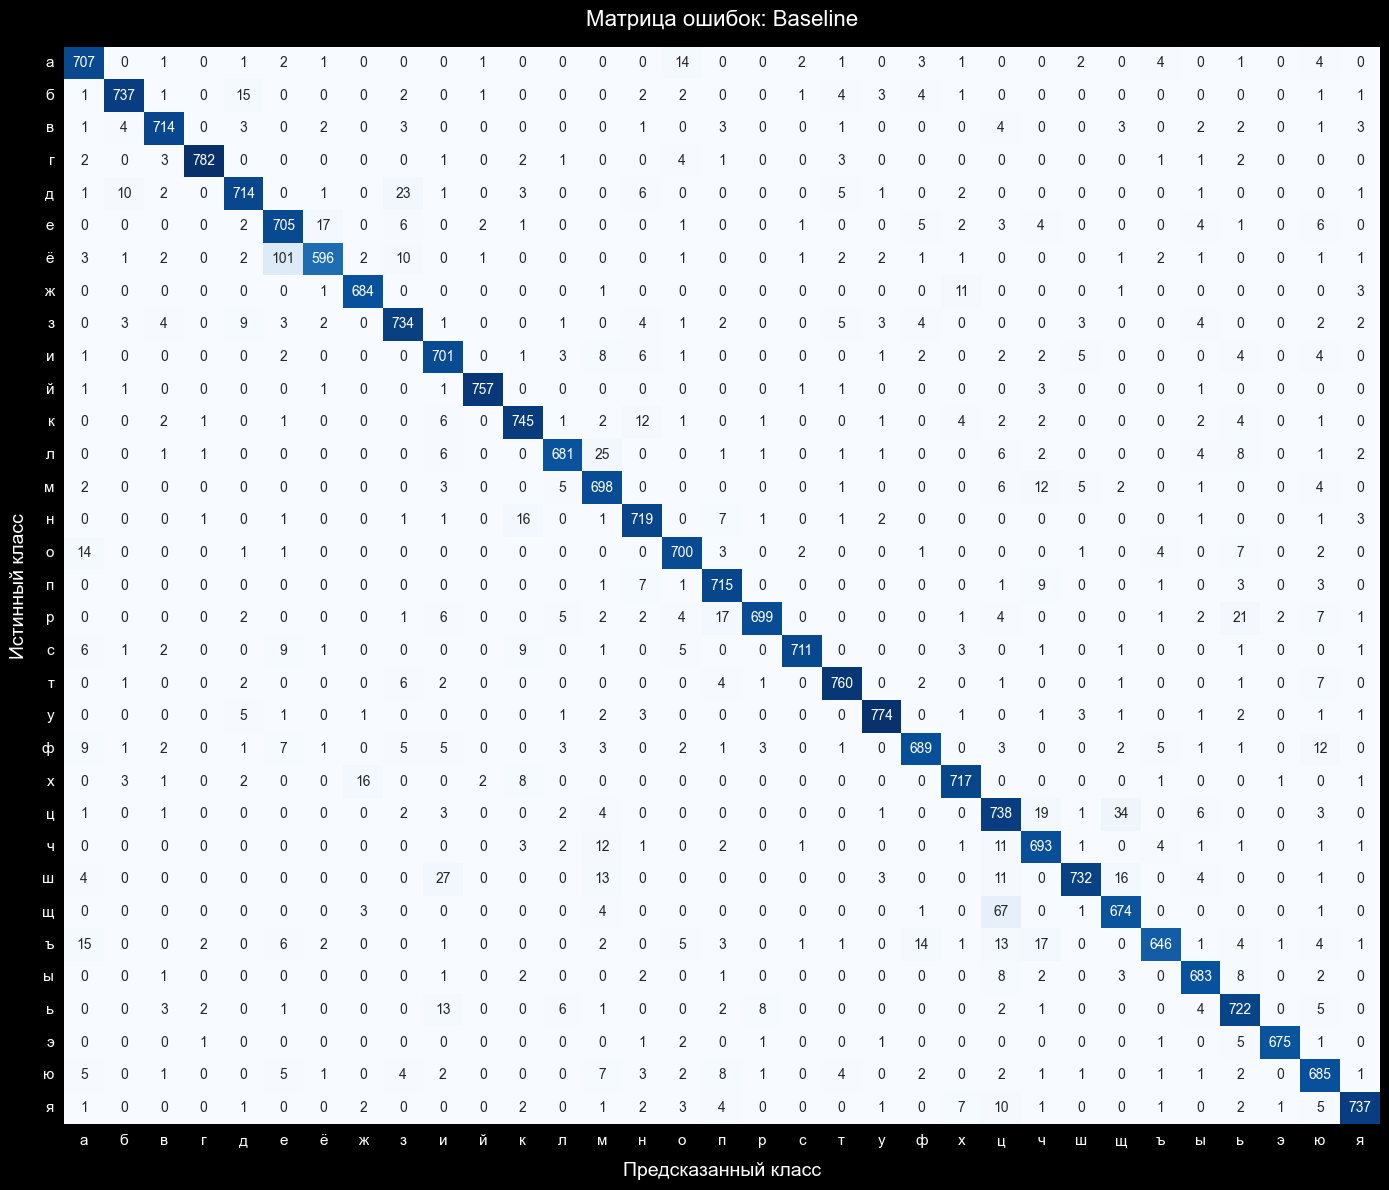

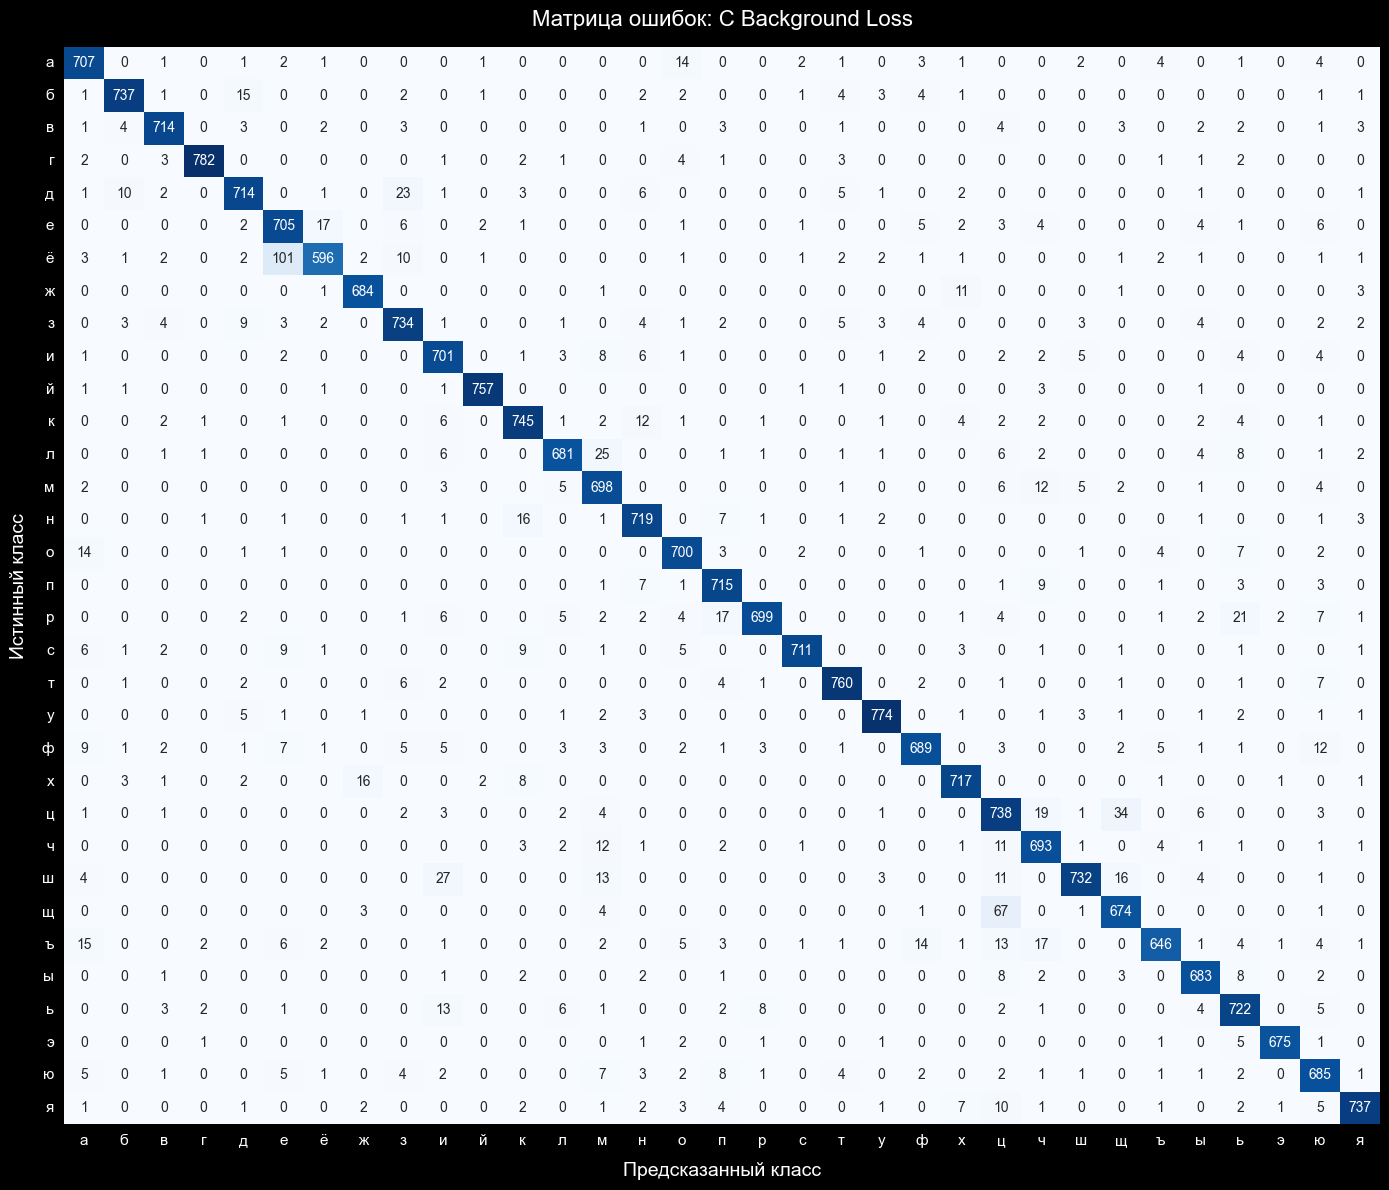

In [5]:
# 1. 4KB Model (Cyrillic)
model_4kb_cyr, hist_4kb_cyr = run_experiment(
    config_path='configs/lenet_4kb.json',
    train_loader=train_loader_cyr,
    test_loader=test_loader_cyr,
    dataset_name='4KB Cyrillic',
    num_epochs=15,
    bg_loss_alpha=15.0,
    bg_loss_n=2
)


Обучение 2KB Cyrillic (Классов: 33)...
Epoch 1/15


Train Loss: 2.1463 | Train Acc: 0.4345 | BG Loss: 0.0021
Val Loss: 1.3642 | Val Acc: 0.6512

Epoch 2/15


Train Loss: 1.1003 | Train Acc: 0.7198 | BG Loss: 0.0069
Val Loss: 0.8913 | Val Acc: 0.7682

Epoch 3/15


Train Loss: 0.7876 | Train Acc: 0.7971 | BG Loss: 0.0062
Val Loss: 0.6737 | Val Acc: 0.8240

Epoch 4/15


Train Loss: 0.6255 | Train Acc: 0.8357 | BG Loss: 0.0053
Val Loss: 0.5682 | Val Acc: 0.8487

Epoch 5/15


...

Train Loss: nan | Train Acc: 0.0295 | BG Loss: nan
Val Loss: nan | Val Acc: 0.0292

Epoch 12/15


Train Loss: nan | Train Acc: 0.0306 | BG Loss: nan
Val Loss: nan | Val Acc: 0.0310

Epoch 13/15


Train Loss: nan | Train Acc: 0.0303 | BG Loss: nan
Val Loss: nan | Val Acc: 0.0309

Epoch 14/15


Train Loss: nan | Train Acc: 0.0313 | BG Loss: nan
Val Loss: nan | Val Acc: 0.0293

Epoch 15/15


Train Loss: nan | Train Acc: 0.0302 | BG Loss: nan
Val Loss: nan | Val Acc: 0.0309


Визуализация Grad-CAM (по первому и второму слоям):


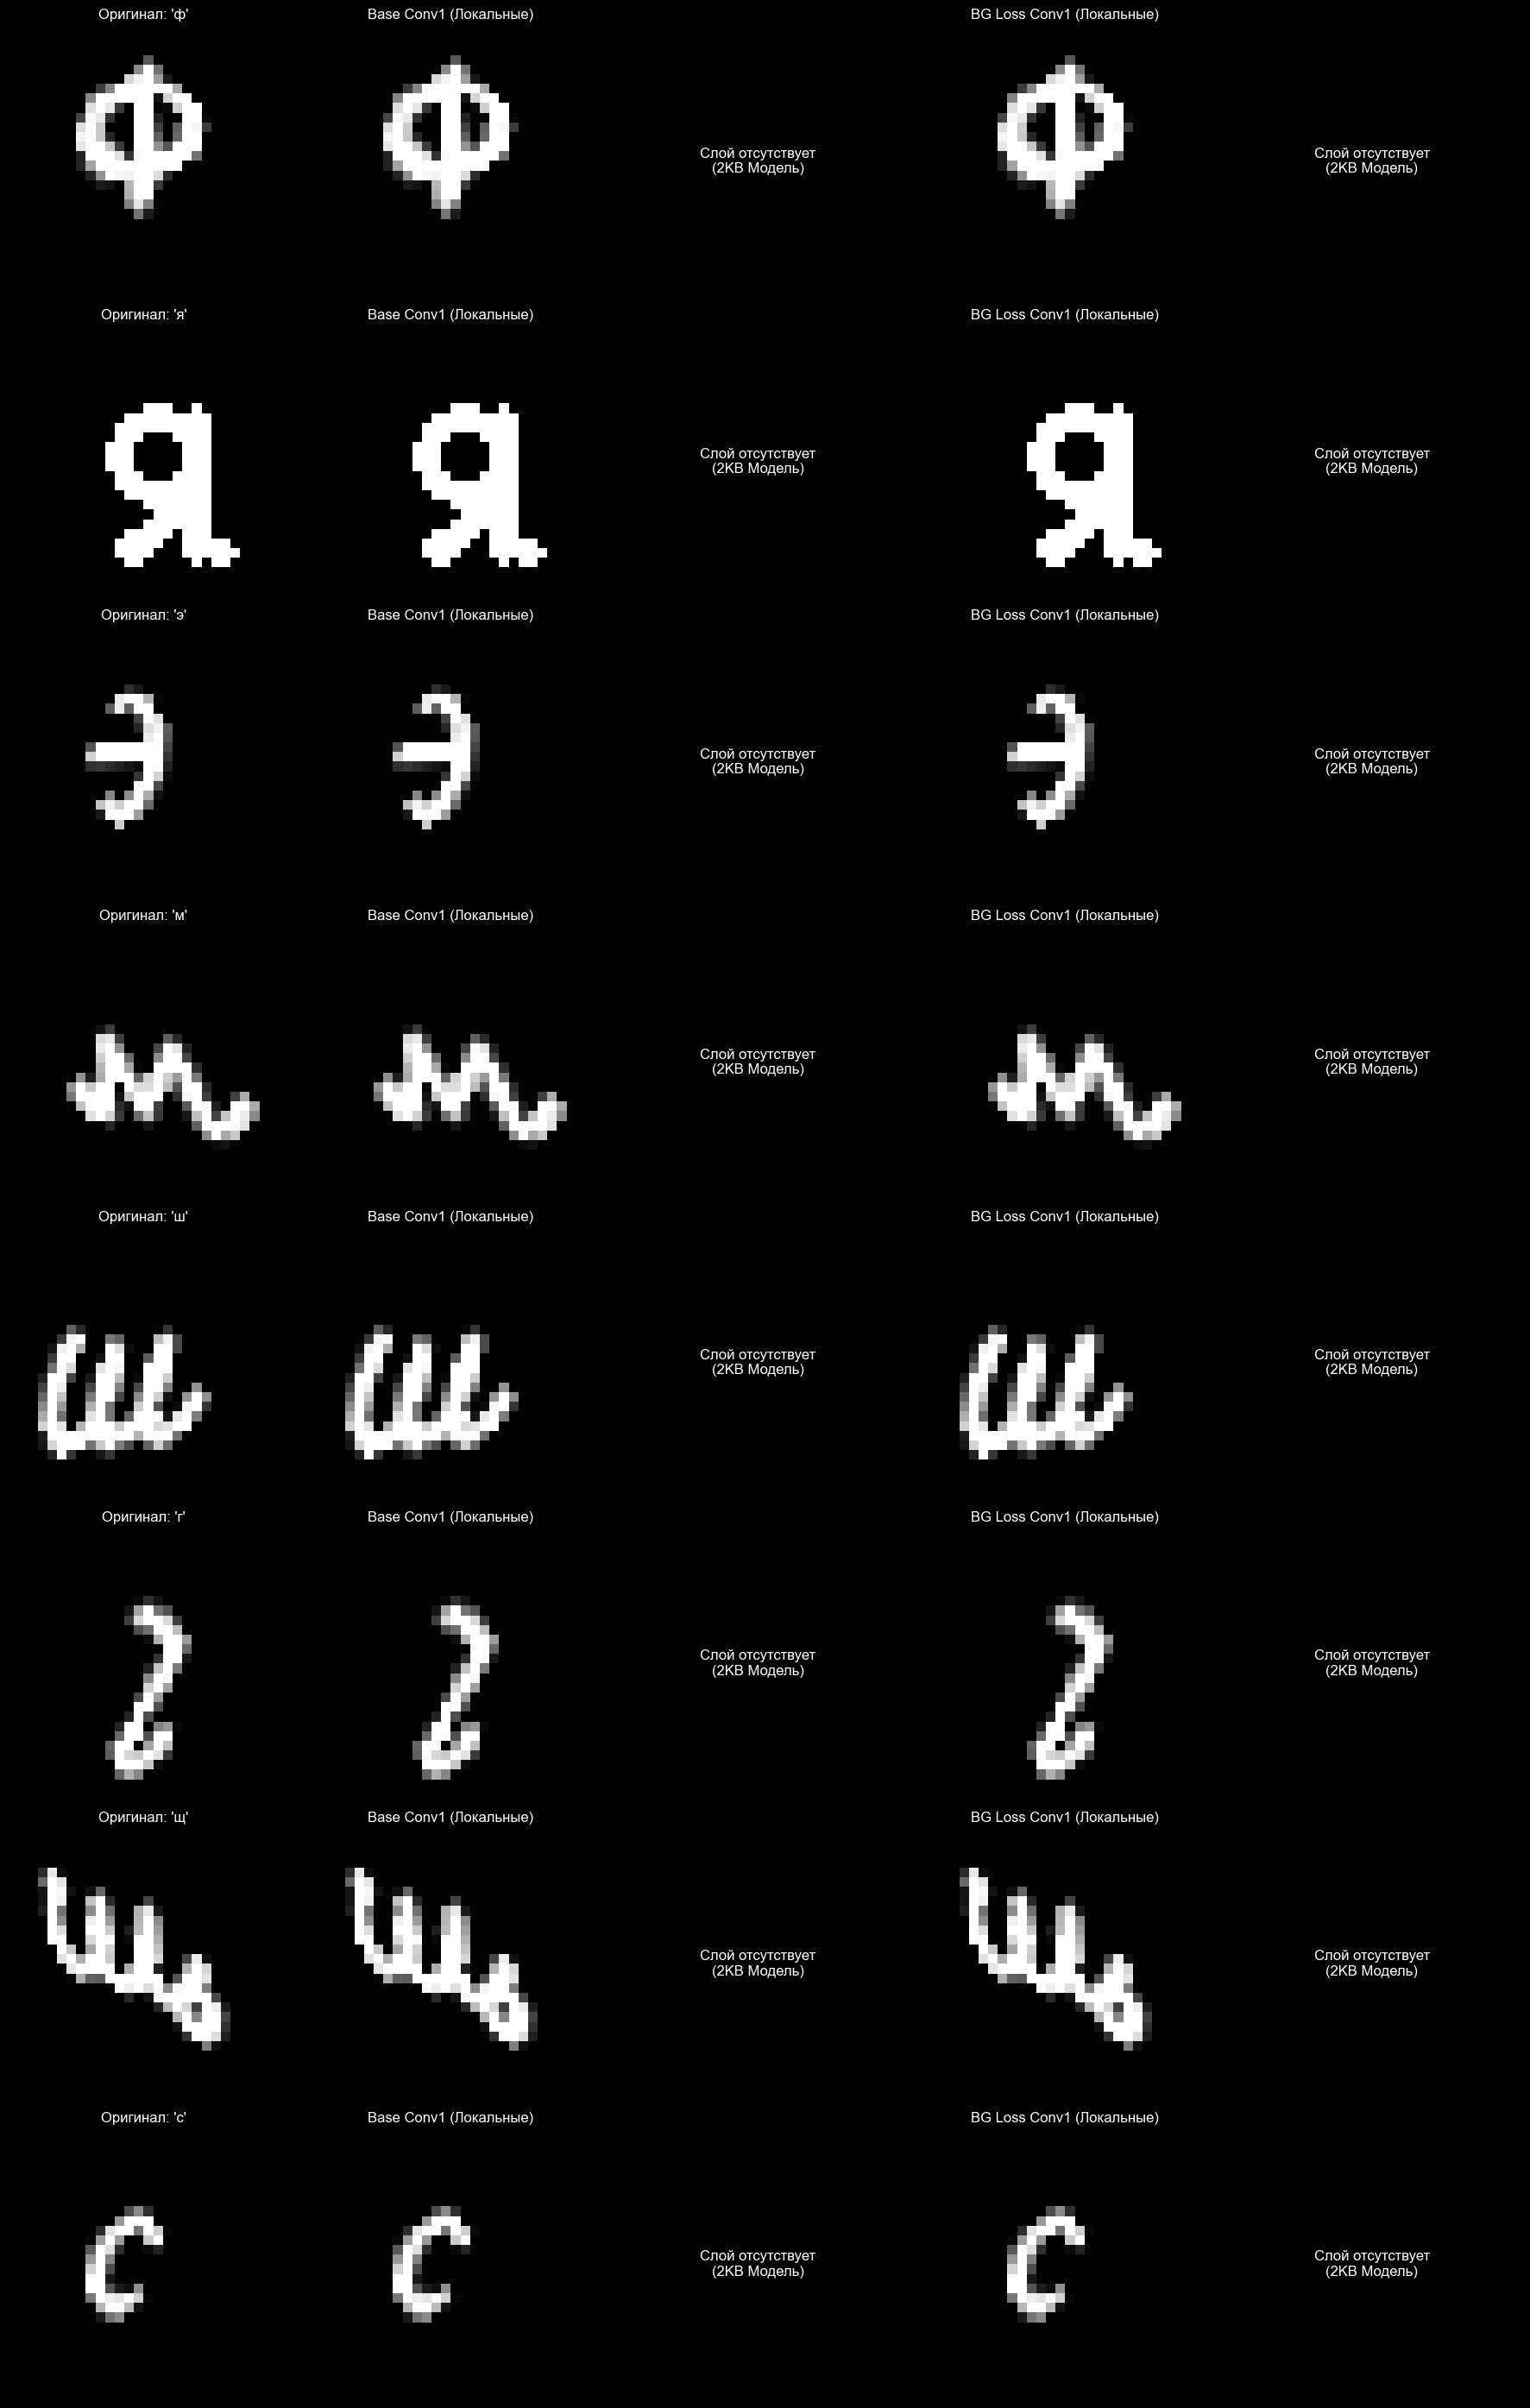


Визуализация Grad-CAM (один слой):


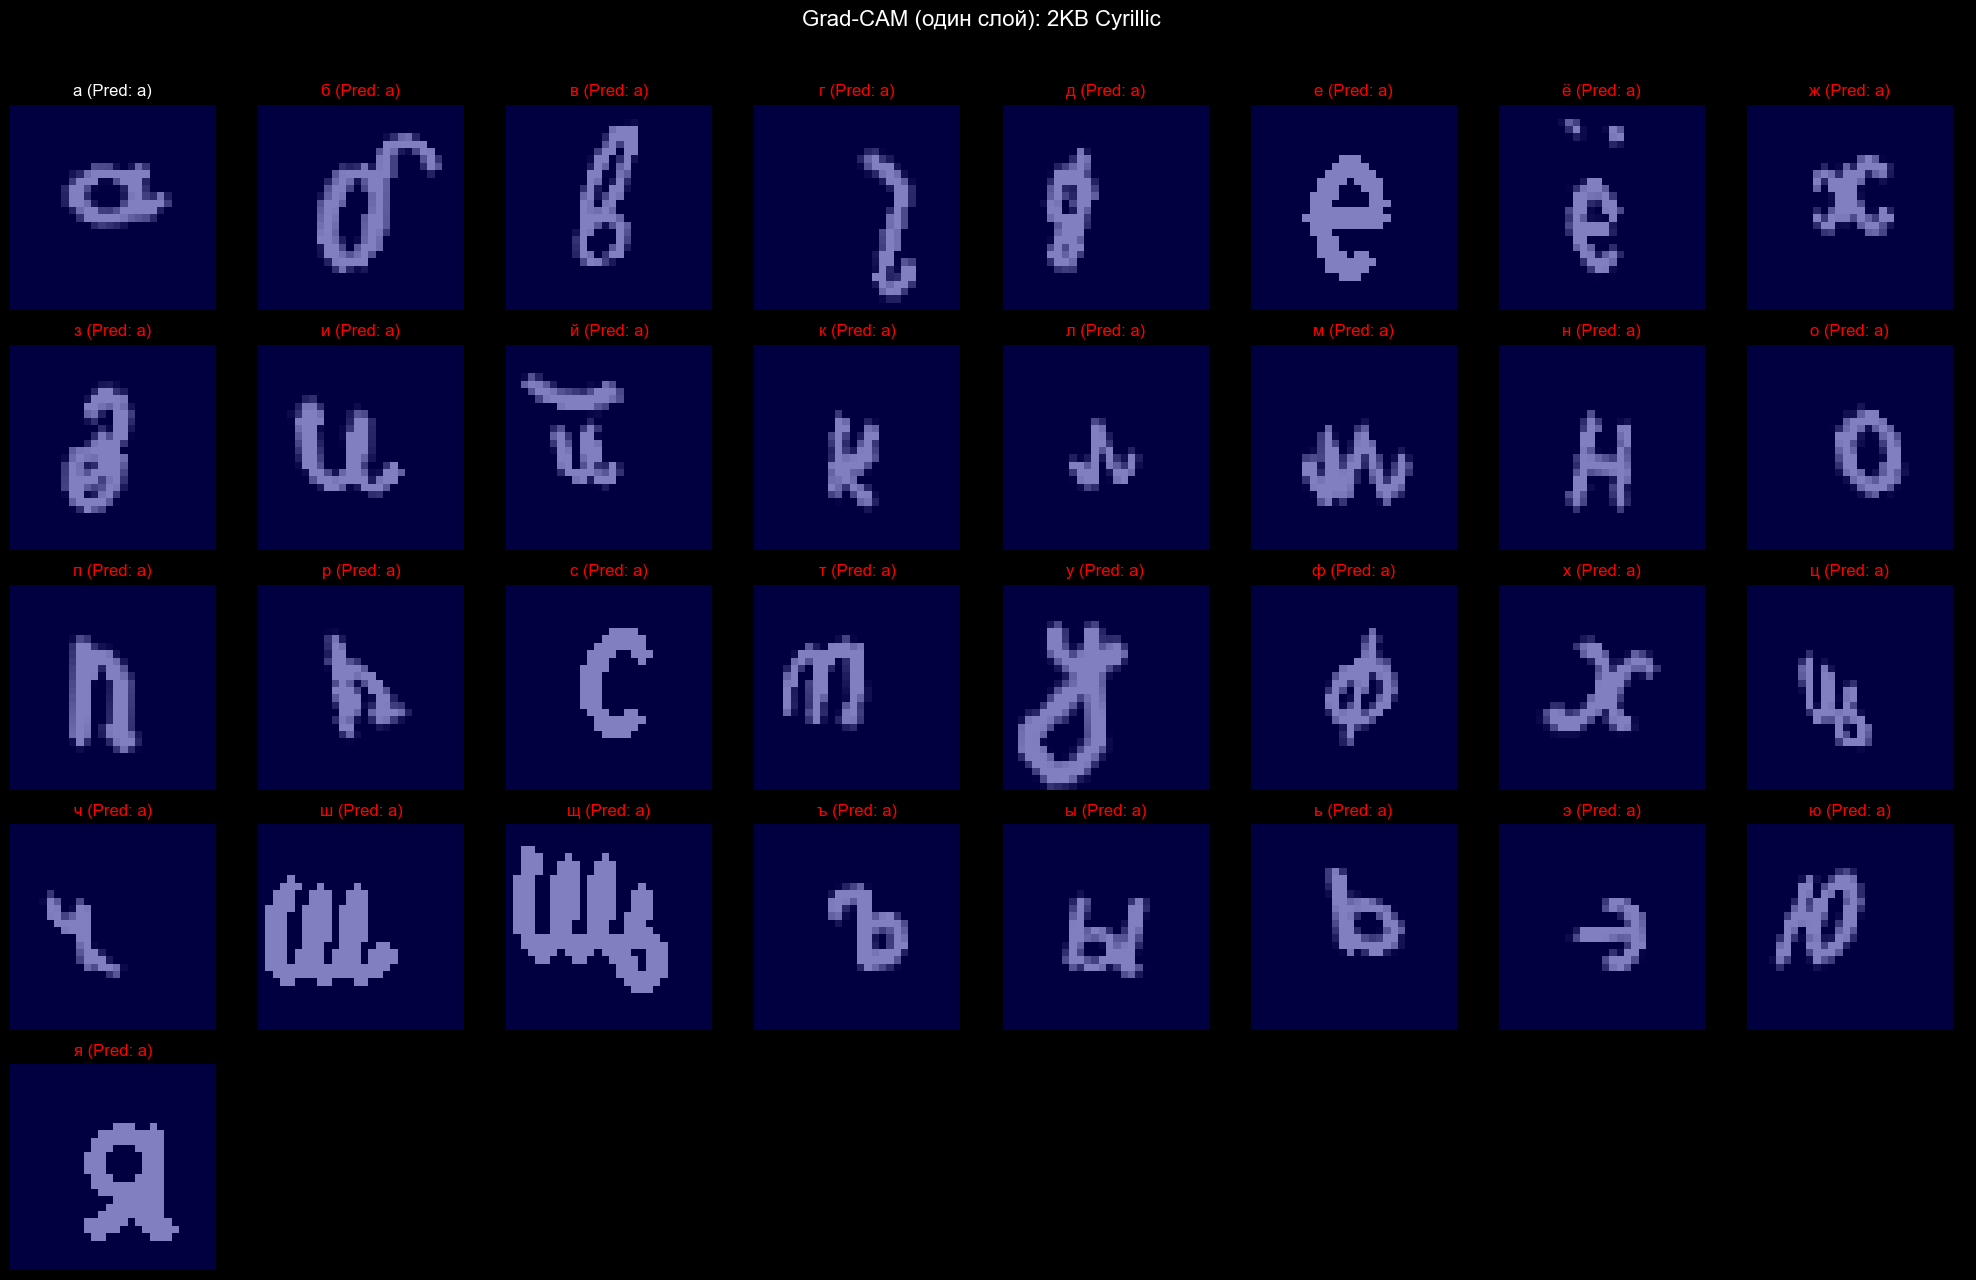


Матрица ошибок:


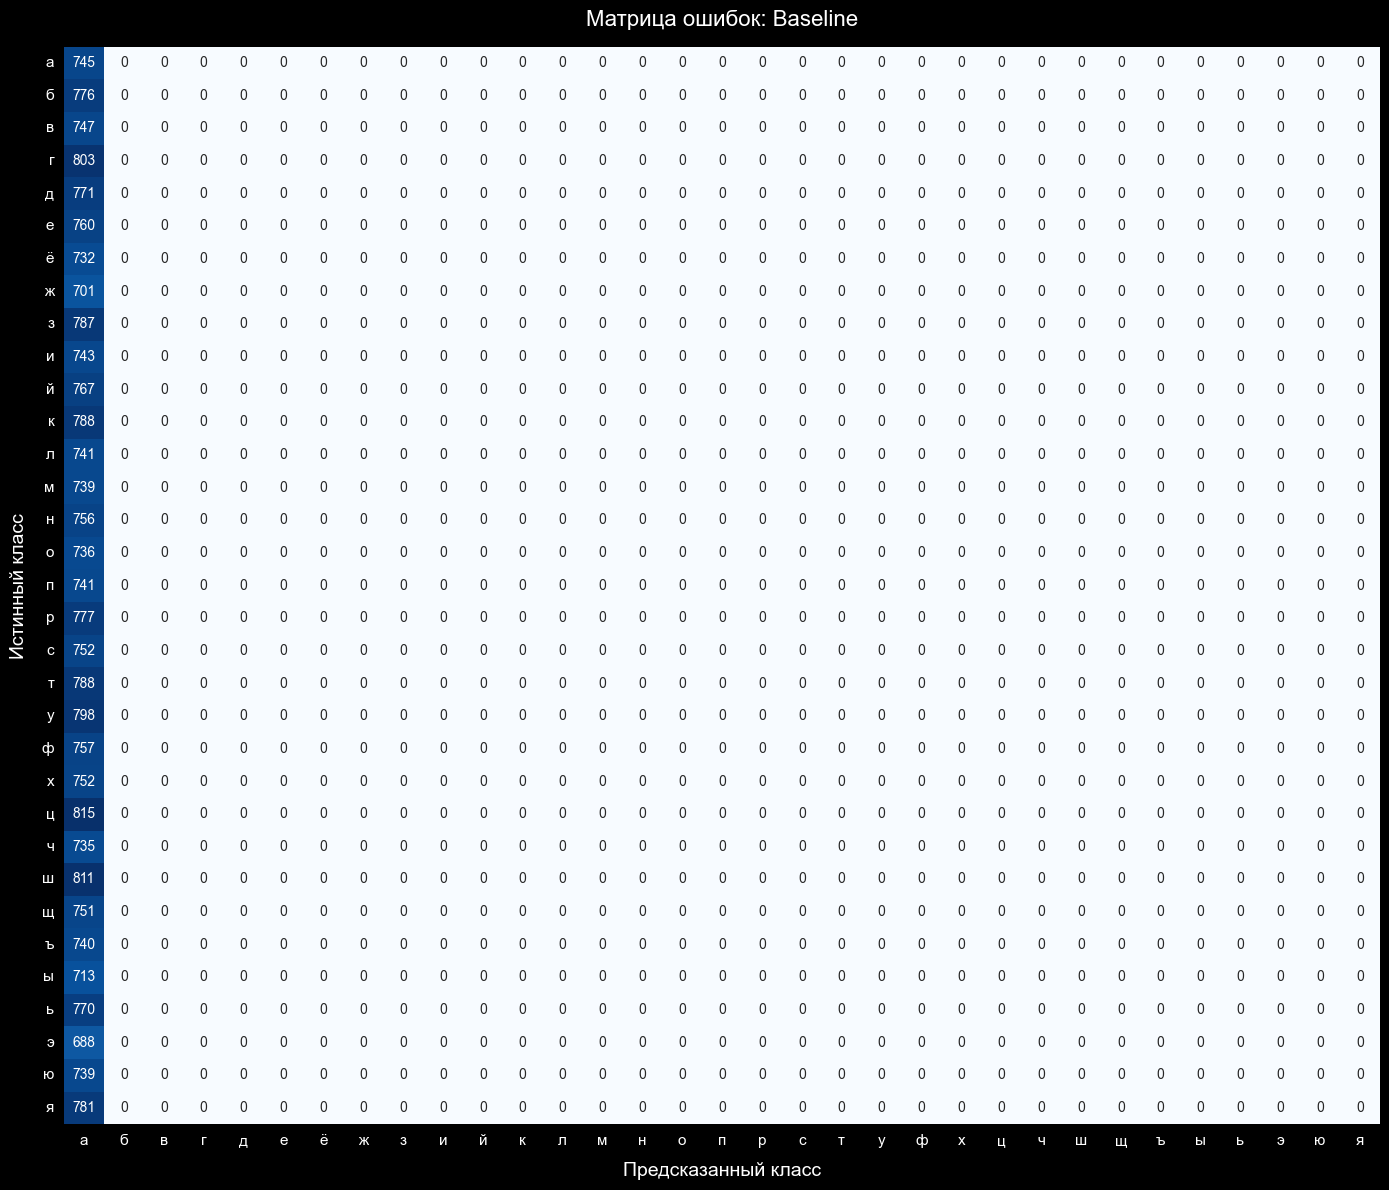

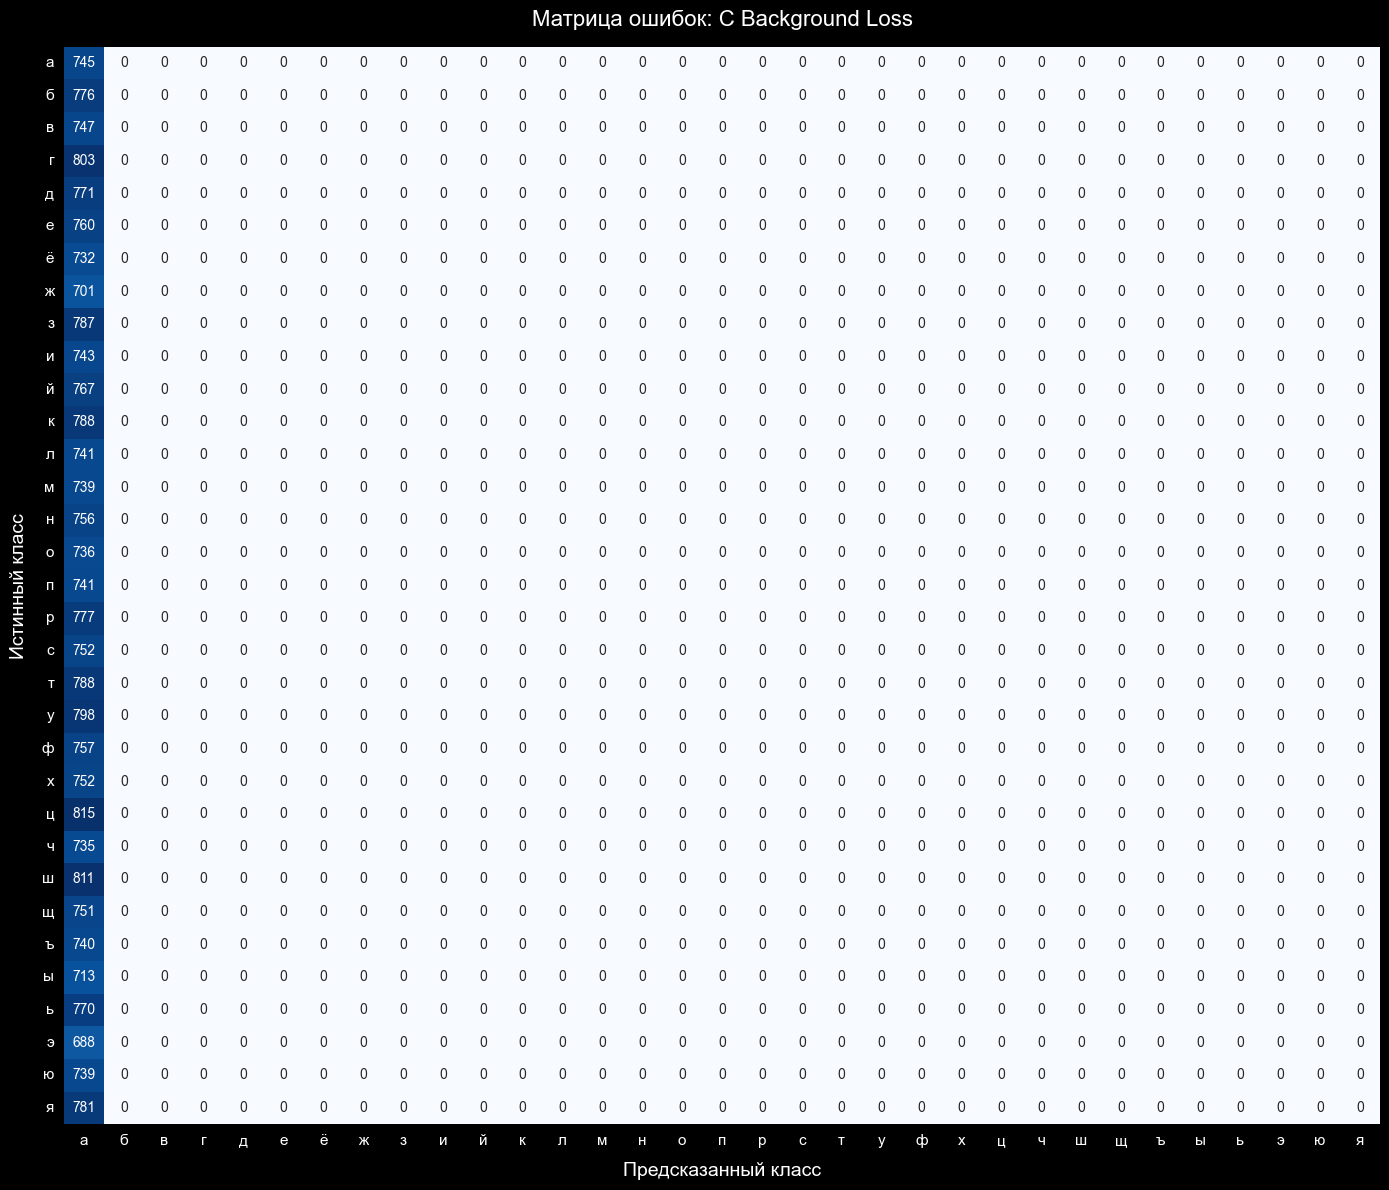

In [5]:
# 2. 2KB Model (Cyrillic)
model_2kb_cyr, hist_2kb_cyr = run_experiment(
    config_path='configs/lenet_2kb.json',
    train_loader=train_loader_cyr,
    test_loader=test_loader_cyr,
    dataset_name='2KB Cyrillic',
    num_epochs=15,
    bg_loss_alpha=15.0,
    bg_loss_n=2,
)


Обучение 4KB Combined (Классов: 43)...
Epoch 1/15


Train Loss: 2.5558 | Train Acc: 0.3594 | BG Loss: 0.0315
Val Loss: 1.7582 | Val Acc: 0.5524

Epoch 2/15


Train Loss: 1.4148 | Train Acc: 0.6379 | BG Loss: 0.0002
Val Loss: 1.1816 | Val Acc: 0.6943

Epoch 3/15


Train Loss: 1.0577 | Train Acc: 0.7240 | BG Loss: 0.0005
Val Loss: 0.9391 | Val Acc: 0.7500

Epoch 4/15


Train Loss: 0.8761 | Train Acc: 0.7702 | BG Loss: 0.0004
Val Loss: 0.8096 | Val Acc: 0.7823

Epoch 5/15


...

Train Loss: 0.4888 | Train Acc: 0.8643 | BG Loss: 0.0003
Val Loss: 0.4849 | Val Acc: 0.8624

Epoch 12/15


Train Loss: 0.4667 | Train Acc: 0.8696 | BG Loss: 0.0004
Val Loss: 0.4652 | Val Acc: 0.8705

Epoch 13/15


Train Loss: 0.4582 | Train Acc: 0.8704 | BG Loss: 0.0004
Val Loss: 0.4458 | Val Acc: 0.8754

Epoch 14/15


Train Loss: 0.4410 | Train Acc: 0.8756 | BG Loss: 0.0005
Val Loss: 0.4308 | Val Acc: 0.8787

Epoch 15/15


Train Loss: 0.4276 | Train Acc: 0.8791 | BG Loss: 0.0005
Val Loss: 0.4205 | Val Acc: 0.8811


Визуализация Grad-CAM (по первому и второму слоям):


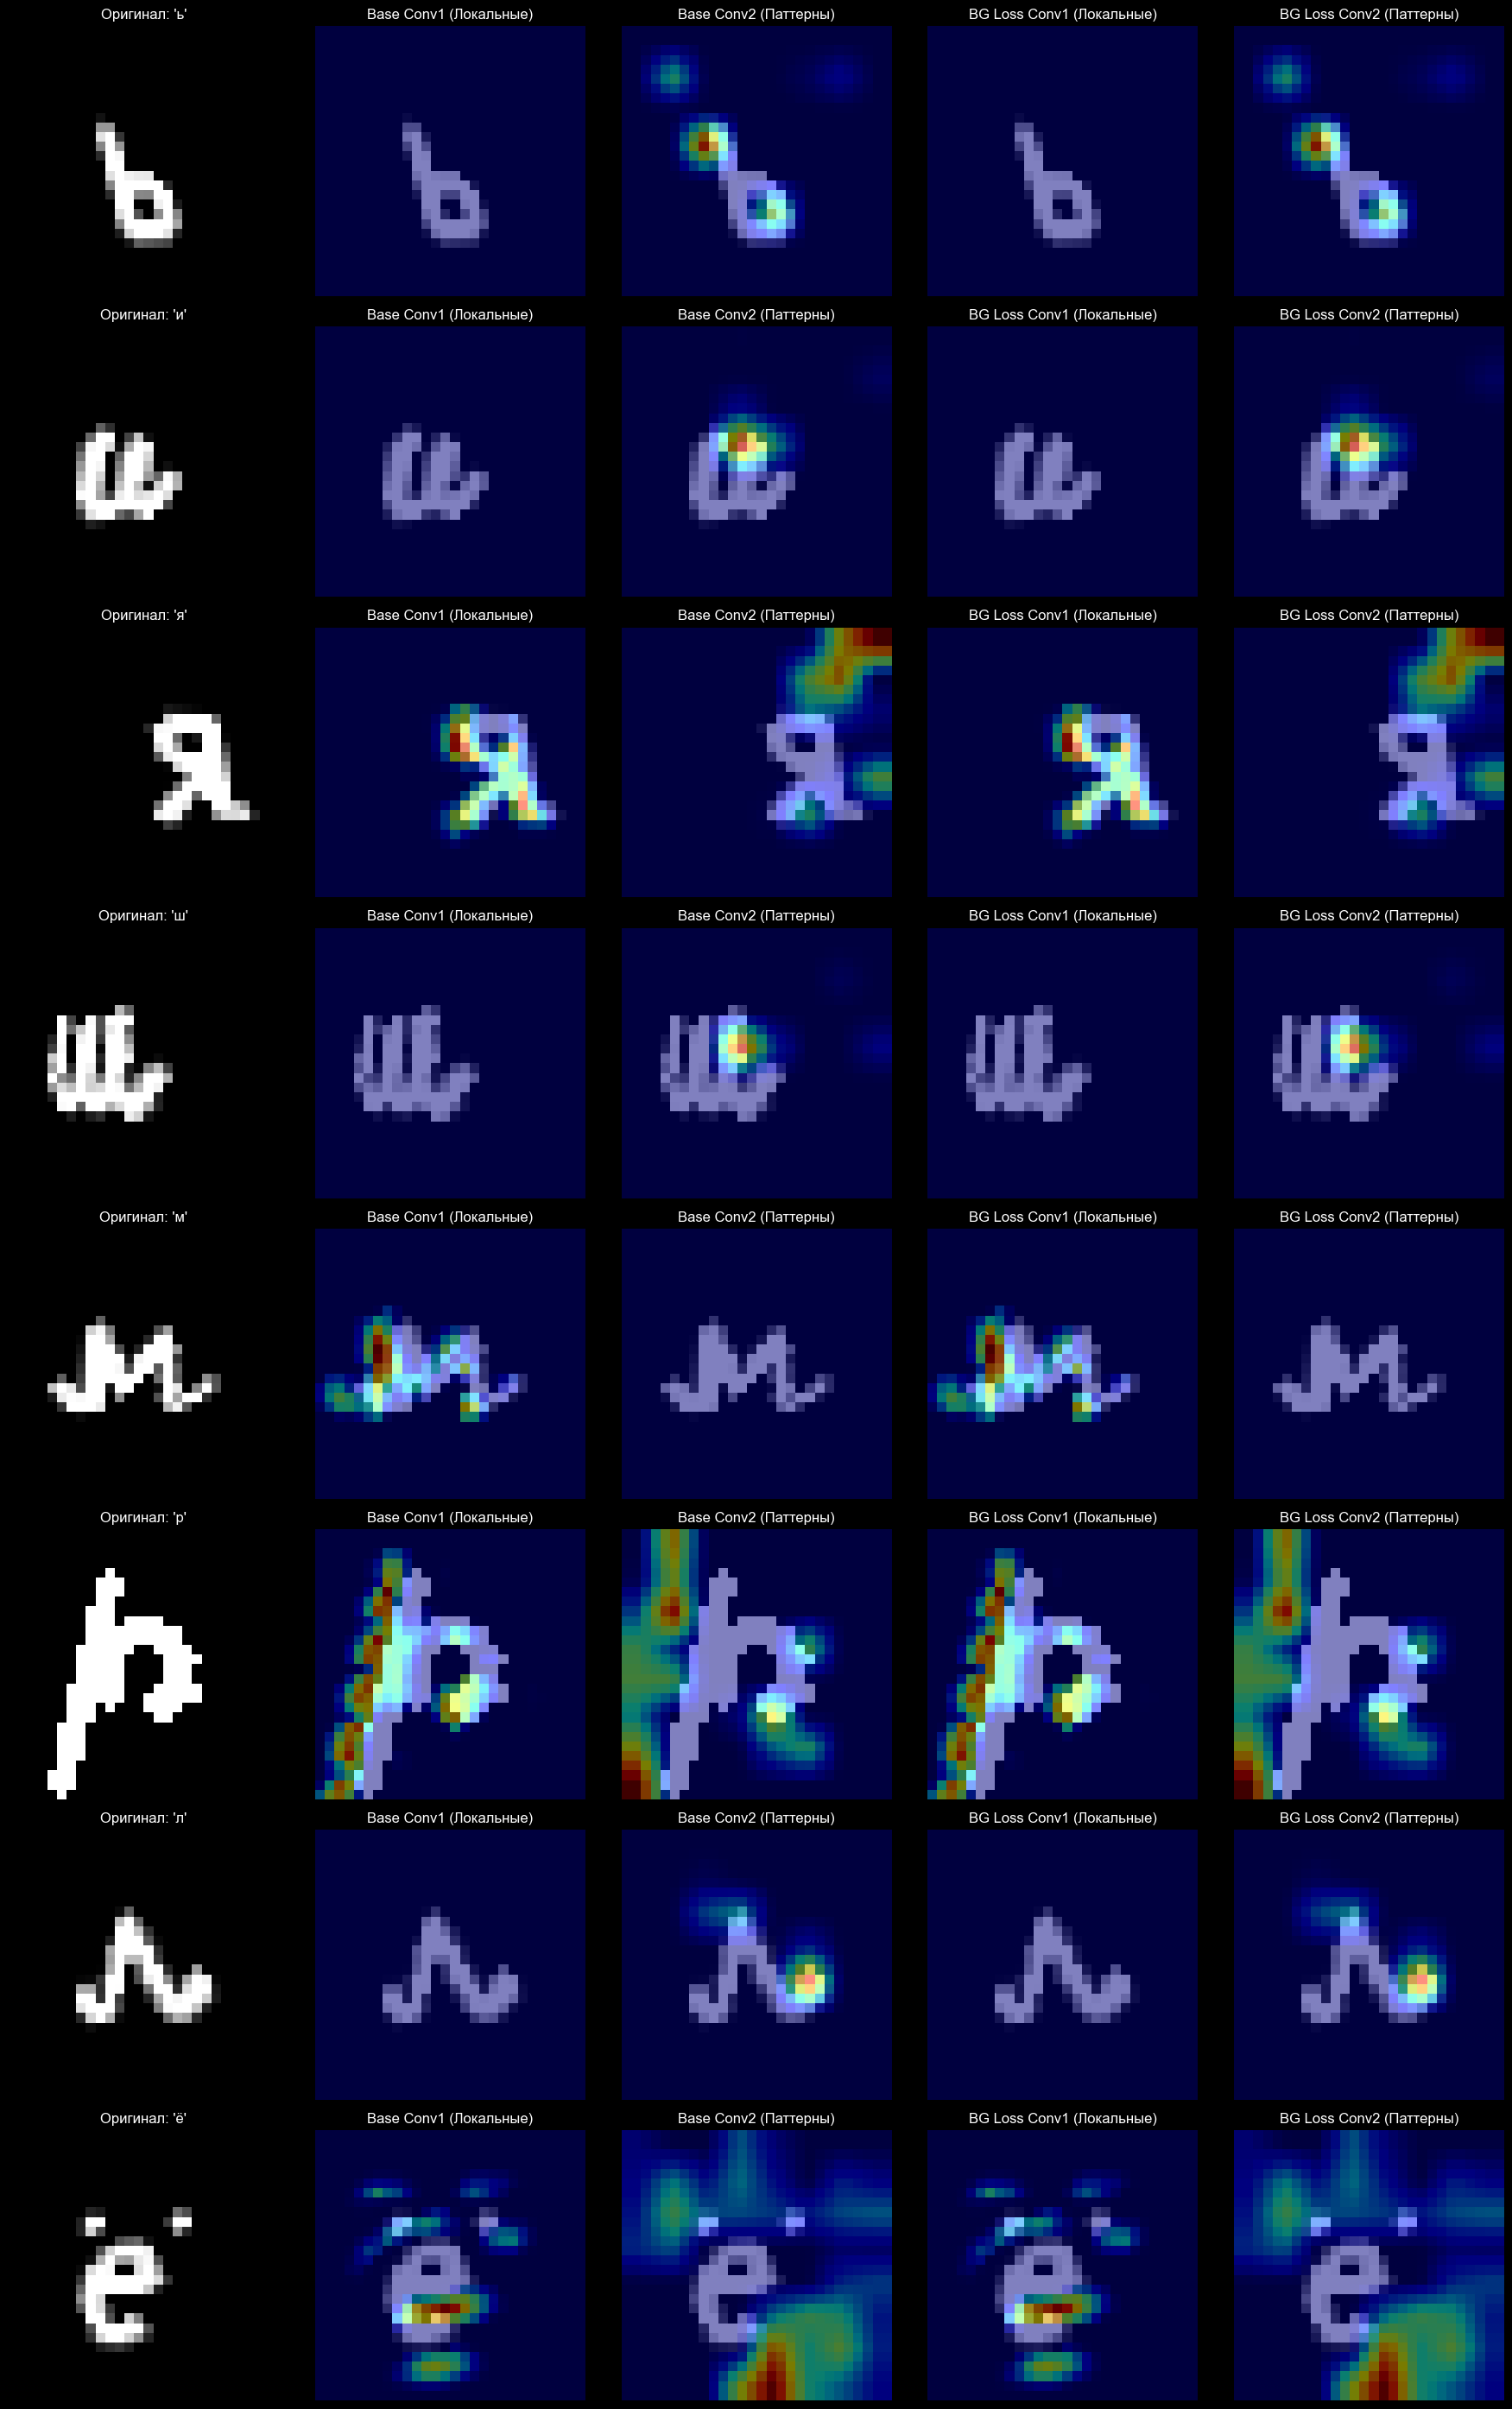


Визуализация Grad-CAM (Friend Style):


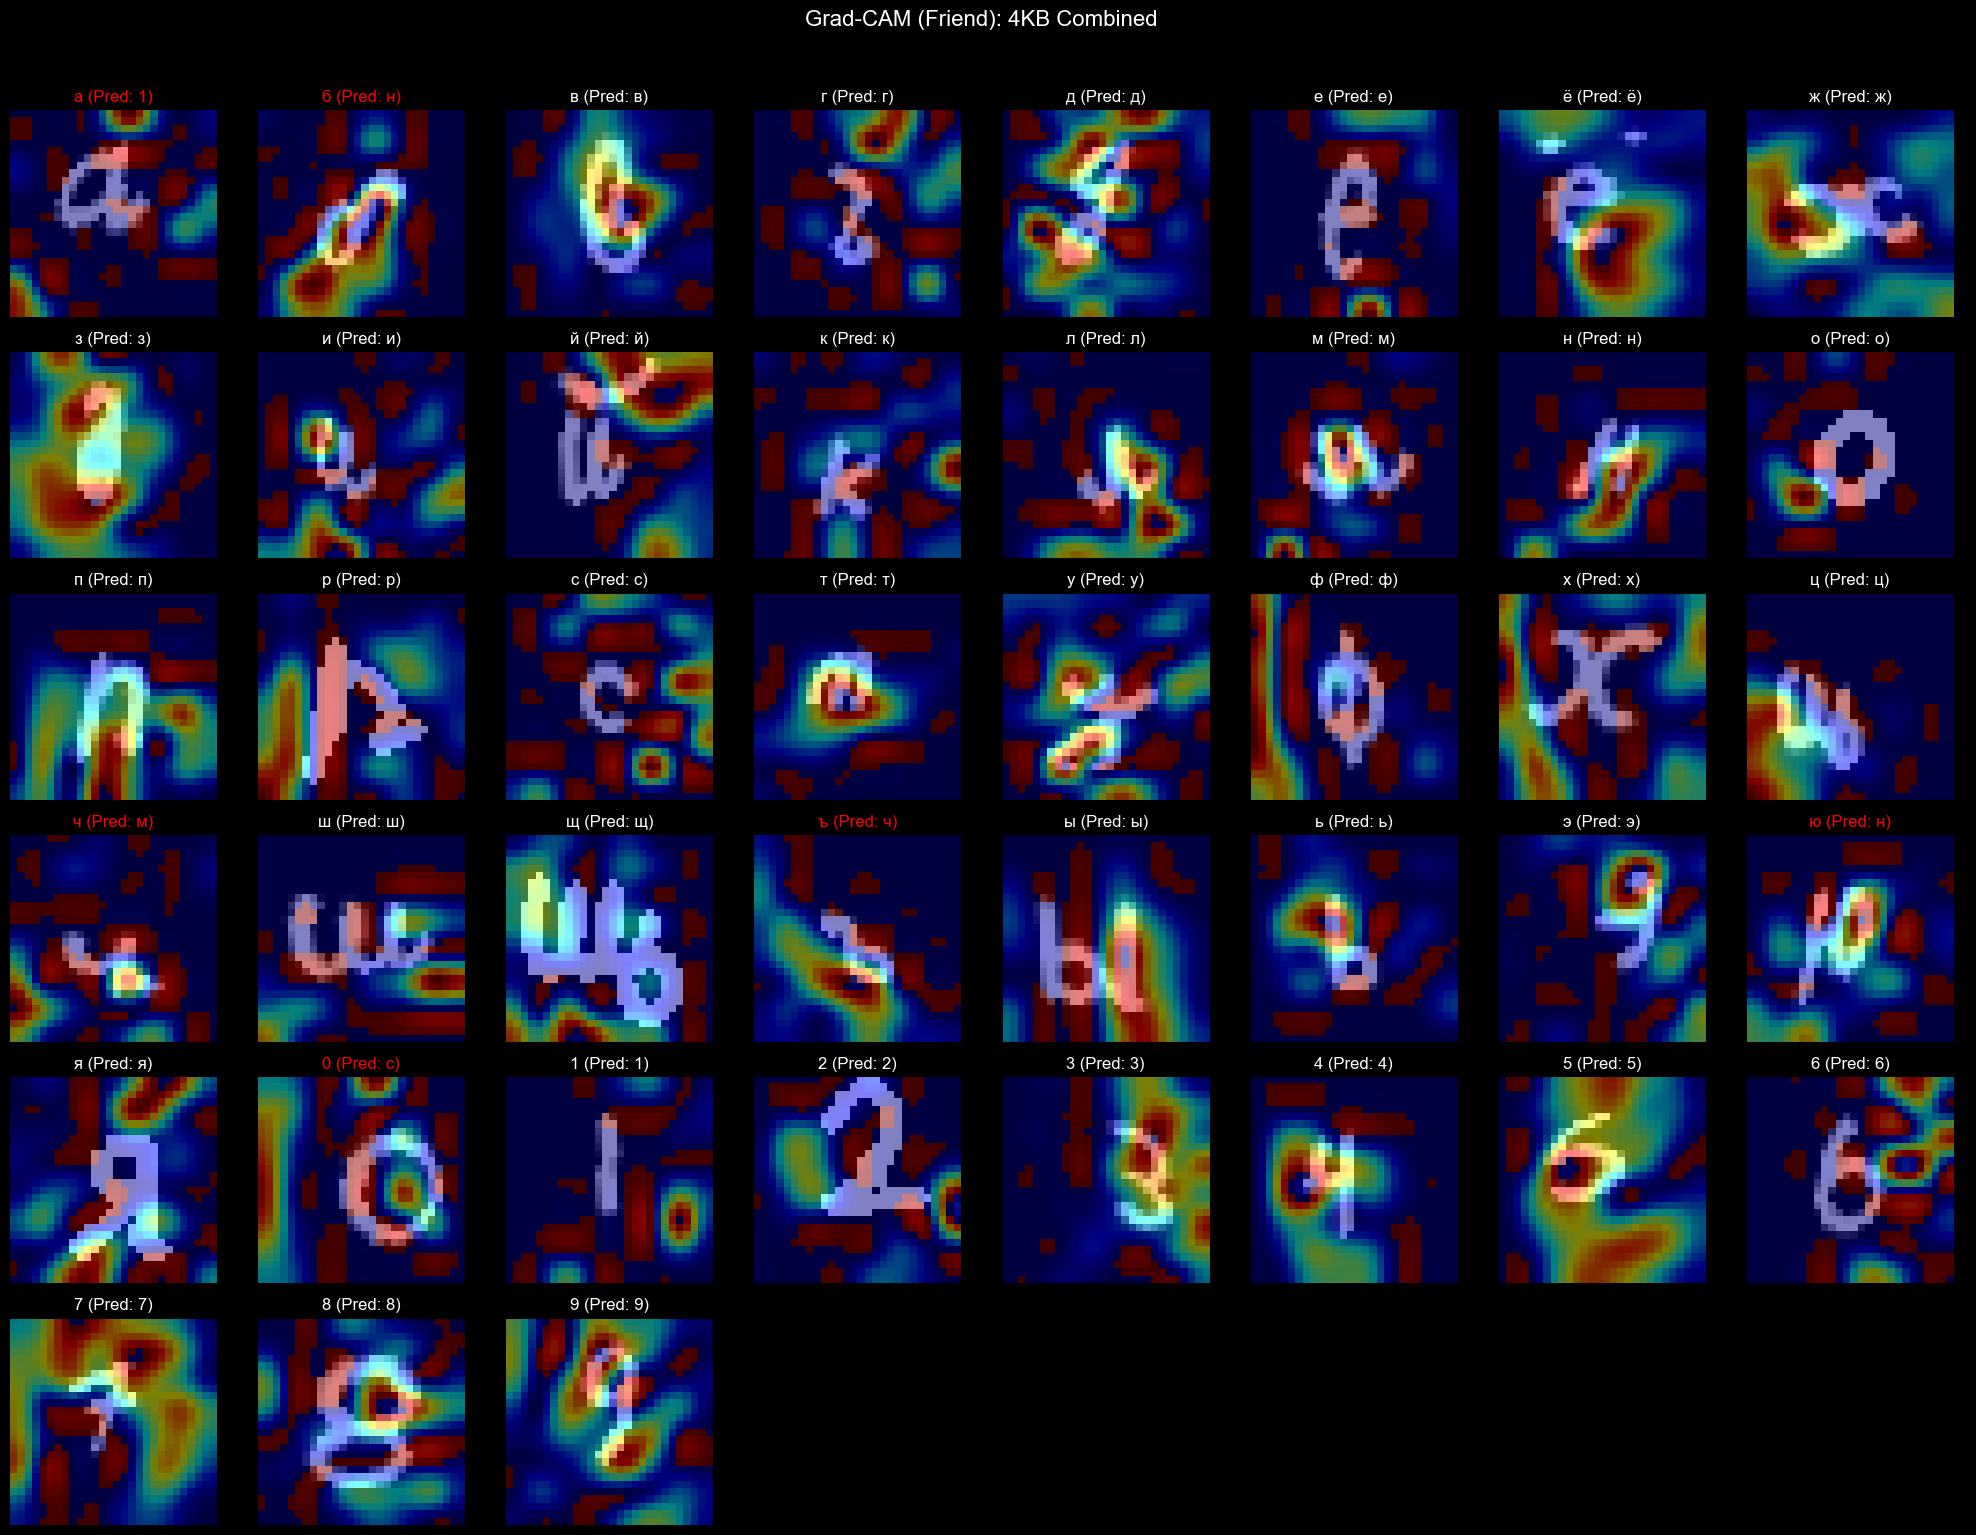


Матрица ошибок:


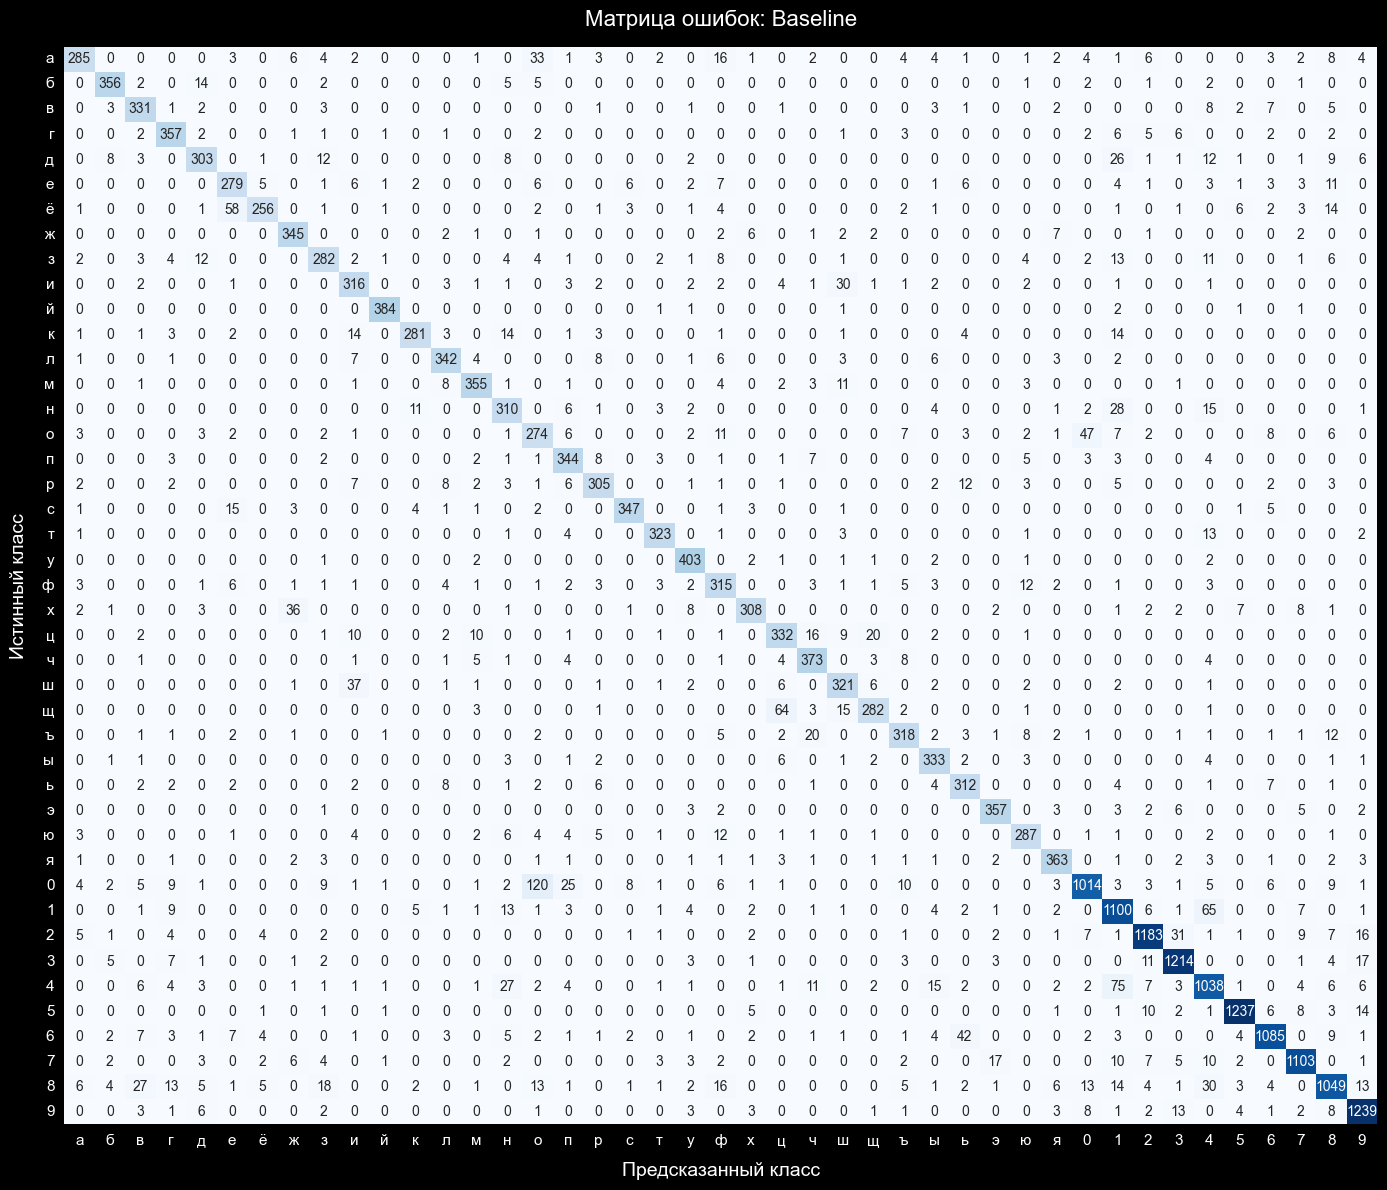

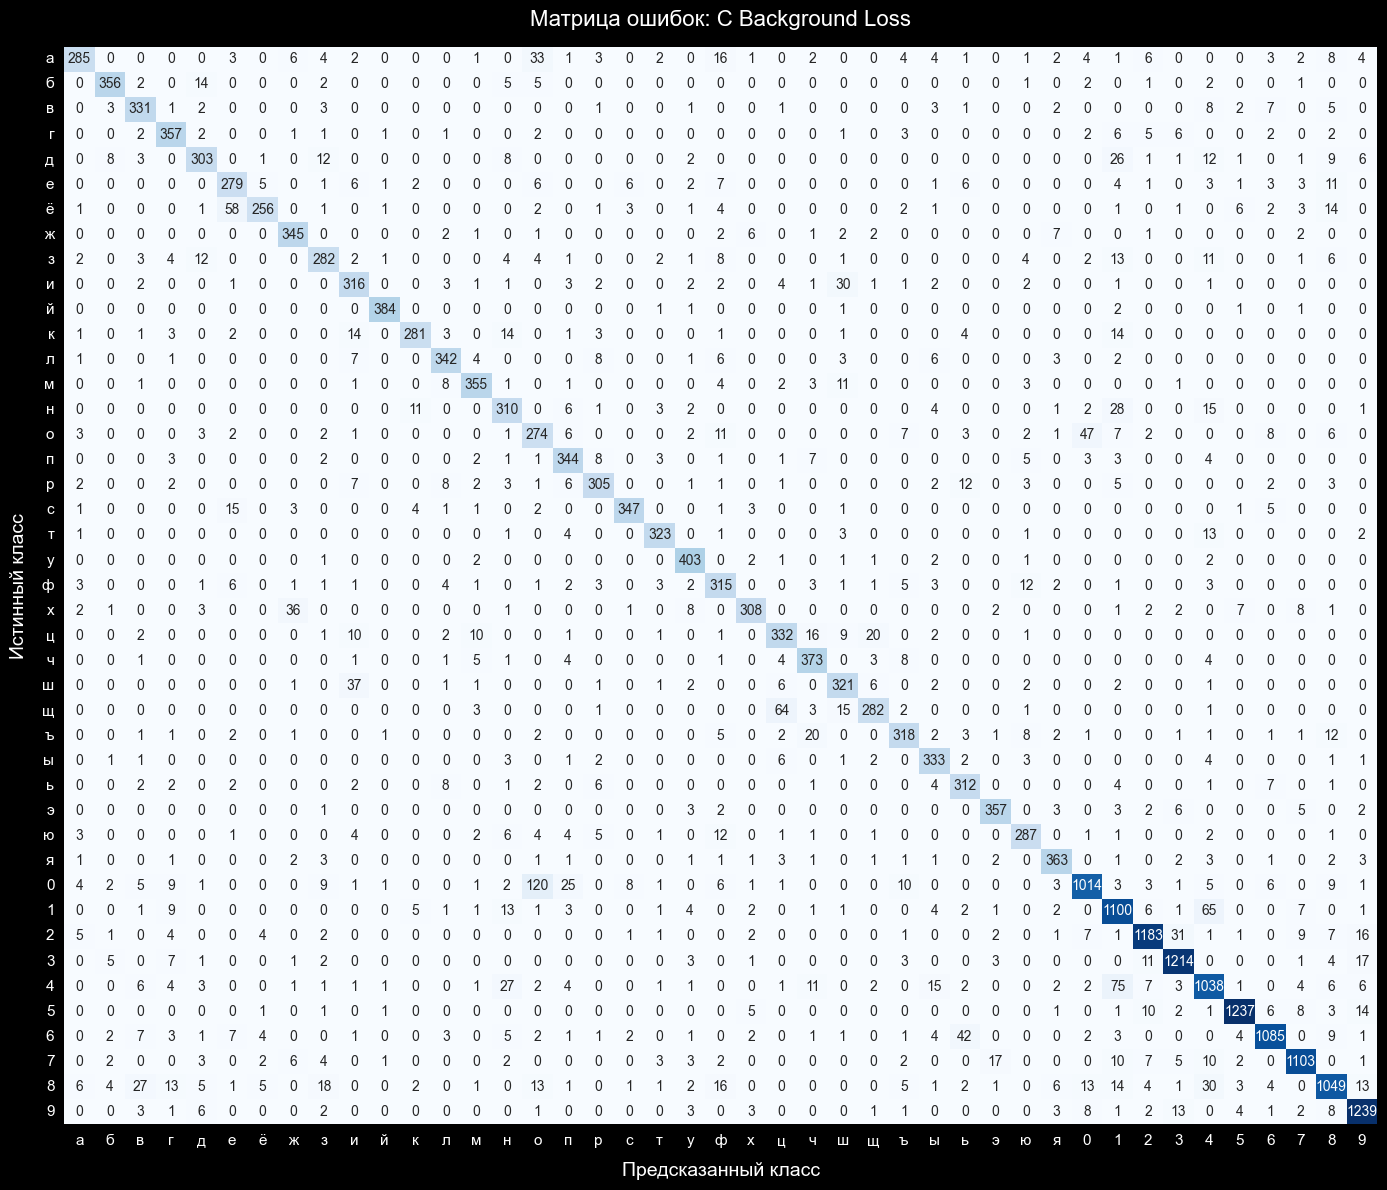

In [5]:
# 3. 4KB Model (Cyrillic + Digits)
model_4kb_combined, hist_4kb_combined = run_experiment(
    config_path='configs/lenet_4kb.json',
    train_loader=train_loader_combined,
    test_loader=test_loader_combined,
    dataset_name='4KB Combined',
    num_epochs=15,
    bg_loss_alpha=15.0,
    bg_loss_n=2
)

In [ ]:
# 4. 2KB Model (Cyrillic + Digits)
model_2kb_combined, hist_2kb_combined = run_experiment(
    config_path='configs/lenet_2kb.json',
    train_loader=train_loader_combined,
    test_loader=test_loader_combined,
    dataset_name='2KB Combined',
    num_epochs=15,
    bg_loss_alpha=15.0,
    bg_loss_n=2,
)


Обучение 2KB Combined (Классов: 43)...
Epoch 1/15


Training:  20%|██        | 59/293 [00:11<00:43,  5.39it/s, loss=3.01]